# Entrega 01 — Análise Inferencial de Dados

Este notebook realiza a análise descritiva completa da base de dados financeiros/orçamentários, contemplando:

1. Carregamento e entendimento da estrutura dos dados
2. Medidas de posição (média, mediana, moda)
3. Medidas de dispersão (variância, desvio padrão, amplitude)
4. Identificação de valores atípicos (outliers)
5. Representações gráficas (histogramas e boxplots)
6. Síntese dos achados

## 1. Importação das bibliotecas e carregamento dos dados

In [2]:
import pandas as pd
import numpy as np
from scipy import stats as sstats
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 120
})
COLORS = {'BAL': '#2E5266', 'DRE': '#6E8898', 'FLU': '#9FB8AD'}

df = pd.read_excel('base_analitica_amostra.xlsx', sheet_name='in')
df['valor_mi'] = df['valor'] / 1e6   # valor convertido para R$ milhões, para facilitar leitura
df.head()

,ano,ano_num,cenario,cenario_num,peso_cenario,demonstrativo,conta,conta_normalizada,valor,valor_mi
0,Ano 1,1,Total Cen_00001,1,0.025139,BAL,BAL - Capital Social,BAL - Capital Social,-3.096189e+08,-309.618939
1,Ano 1,1,Total Cen_00001,1,0.025139,BAL,BAL - Patrimônio Líquido,BAL - Patrimônio Líquido,-2.014435e+09,-2014.435237
2,Ano 1,1,Total Cen_00001,1,0.025139,BAL,BAL - Prov para Contingências,BAL - Prov para Contingências,-3.850246e+07,-38.502465
3,Ano 1,1,Total Cen_00001,1,0.025139,BAL,BAL - Reserva de Retenção de Lucros,BAL - Reserva de Retenção de Lucros,-3.143802e+09,-3143.802181
4,Ano 1,1,Total Cen_00001,1,0.025139,BAL,BAL - Reservas Legais,BAL - Reservas Legais,-6.192379e+07,-61.923788


## 2. Entendimento da estrutura dos dados



In [3]:
print("Dimensão:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)
print("\nValores nulos por coluna:")
print(df.isna().sum())

Dimensão: (1000, 10)

Tipos de dados:
ano                   object
ano_num                int64
cenario               object
cenario_num            int64
peso_cenario         float64
demonstrativo         object
conta                 object
conta_normalizada     object
valor                float64
valor_mi             float64
dtype: object

Valores nulos por coluna:
ano                  0
ano_num              0
cenario              0
cenario_num          0
peso_cenario         0
demonstrativo        0
conta                0
conta_normalizada    0
valor                0
valor_mi             0
dtype: int64


In [4]:
for col in ['ano', 'cenario', 'demonstrativo']:
    print(f"{col}: {df[col].nunique()} valores únicos ->", df[col].unique()[:5])
print("\nnº de contas distintas:", df['conta_normalizada'].nunique())
print("\nRegistros por demonstrativo:")
print(df['demonstrativo'].value_counts())

ano: 1 valores únicos -> ['Ano 1']
cenario: 15 valores únicos -> ['Total Cen_00001' 'Total Cen_00002' 'Total Cen_00003' 'Total Cen_00004'
 'Total Cen_00005']
demonstrativo: 3 valores únicos -> ['BAL' 'DRE' 'FLU']

nº de contas distintas: 68

Registros por demonstrativo:
demonstrativo
BAL    630
DRE    202
FLU    168
Name: count, dtype: int64


Contas constantes entre cenários: 30
Contas que variam entre cenários: 38


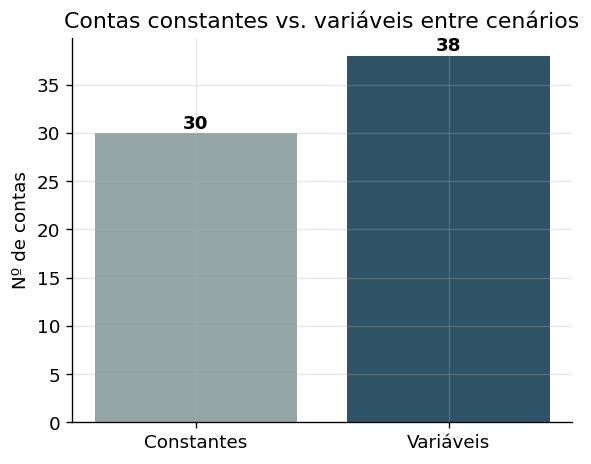

In [5]:
nunique_por_conta = df.groupby('conta_normalizada')['valor'].nunique()
constantes = (nunique_por_conta == 1).sum()
variaveis = df['conta_normalizada'].nunique() - constantes
print(f"Contas constantes entre cenários: {constantes}")
print(f"Contas que variam entre cenários: {variaveis}")

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(['Constantes', 'Variáveis'], [constantes, variaveis], color=['#95A5A6', '#2E5266'])
for i, v in enumerate([constantes, variaveis]):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
ax.set_ylabel('Nº de contas')
ax.set_title('Contas constantes vs. variáveis entre cenários')
plt.tight_layout()
plt.show()

## 3. Medidas de posição (média, mediana e moda)



In [6]:
def descreve(serie):
    s = serie.dropna()
    moda = s.mode()
    moda_val = moda.iloc[0] if len(moda) else np.nan
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = s[(s < lim_inf) | (s > lim_sup)]
    return pd.Series({
        'n': s.count(),
        'media': s.mean(),
        'mediana': s.median(),
        'moda': moda_val,
        'variancia': s.var(ddof=1),
        'desvio_padrao': s.std(ddof=1),
        'min': s.min(),
        'max': s.max(),
        'amplitude': s.max() - s.min(),
        'q1': q1, 'q3': q3, 'iqr': iqr,
        'cv_%': (s.std(ddof=1) / s.mean() * 100) if s.mean() != 0 else np.nan,
        'assimetria': sstats.skew(s),
        'curtose': sstats.kurtosis(s),
        'n_outliers_iqr': outliers.count()
    })

stats_geral = descreve(df['valor_mi'])
stats_geral.to_frame('valor (R$ milhões)').round(2)

,valor (R$ milhões)
n,1000.00
media,308.25
mediana,-22.91
moda,-7535.76
variancia,11167236.08
desvio_padrao,3341.74
min,-10649.14
max,12954.95
amplitude,23604.09
q1,-603.06


In [7]:
stats_demonstrativo = df.groupby('demonstrativo')['valor_mi'].apply(descreve).unstack().round(2)
stats_demonstrativo

,n,media,mediana,moda,variancia,desvio_padrao,min,max,amplitude,q1,q3,iqr,cv_%,assimetria,curtose,n_outliers_iqr
demonstrativo,,,,,,,,,,,,,,,,
BAL,630.0,-0.05,-22.91,-7535.76,14361753.33,3789.69,-10649.14,12954.95,23604.09,-309.62,99.12,408.74,-8041294.00,0.86,4.31,210.0
DRE,202.0,1380.93,39.08,39.08,6582090.19,2565.56,-1361.94,6730.50,8092.44,-603.39,3702.06,4305.45,185.78,0.69,-0.92,0.0
FLU,168.0,174.60,-500.39,-1532.41,3019249.40,1737.60,-1532.41,5404.60,6937.01,-771.69,526.92,1298.61,995.20,2.10,3.81,14.0


## 4. Medidas de dispersão (variância, desvio padrão, amplitude e CV)

In [8]:
print("Geral:")
print(stats_geral[['variancia','desvio_padrao','amplitude','iqr','cv_%']].round(2))
print("\nPor demonstrativo:")
print(stats_demonstrativo[['variancia','desvio_padrao','amplitude','iqr','cv_%']].round(2))

Geral:
variancia        11167236.08
desvio_padrao        3341.74
amplitude           23604.09
iqr                  1242.82
cv_%                 1084.10
dtype: float64

Por demonstrativo:
                 variancia  desvio_padrao  amplitude      iqr        cv_%
demonstrativo                                                            
BAL            14361753.33        3789.69   23604.09   408.74 -8041294.00
DRE             6582090.19        2565.56    8092.44  4305.45      185.78
FLU             3019249.40        1737.60    6937.01  1298.61      995.20


## 5. Identificação de valores atípicos (outliers) pelo critério do IQR

In [9]:
outliers_geral = stats_geral['n_outliers_iqr']
print(f"Outliers (critério de 1,5×IQR) no total da base: {int(outliers_geral)} de {len(df)} registros "
      f"({outliers_geral/len(df)*100:.1f}%)")
print()
print(stats_demonstrativo['n_outliers_iqr'])

Outliers (critério de 1,5×IQR) no total da base: 191 de 1000 registros (19.1%)

demonstrativo
BAL    210.0
DRE      0.0
FLU     14.0
Name: n_outliers_iqr, dtype: float64


## 6. Contas com maior variância entre cenários (direcionadores de risco do modelo)

In [ ]:
var_por_conta = df.groupby('conta_normalizada')['valor_mi'].var().sort_values(ascending=False)
top10 = var_por_conta.head(10)
top10.to_frame('variância (R$ milhões²)').round(1)

,variância (R$ milhões²)
conta_normalizada,
DRE - Receita,619.6
FLU - Receita,619.6
DRE - EBITDA,411.7
DRE - Resultado Operacional,393.1
DRE - Resultado Antes do Imposto de Renda,347.2
BAL - Total do Passivo,161.7
BAL - Total do Ativo,161.7
DRE - Despesas Financeiras,149.8
DRE - Resultado Líquido após Equivalência,149.5


## 7. Representações gráficas

### 7.1 Histograma geral

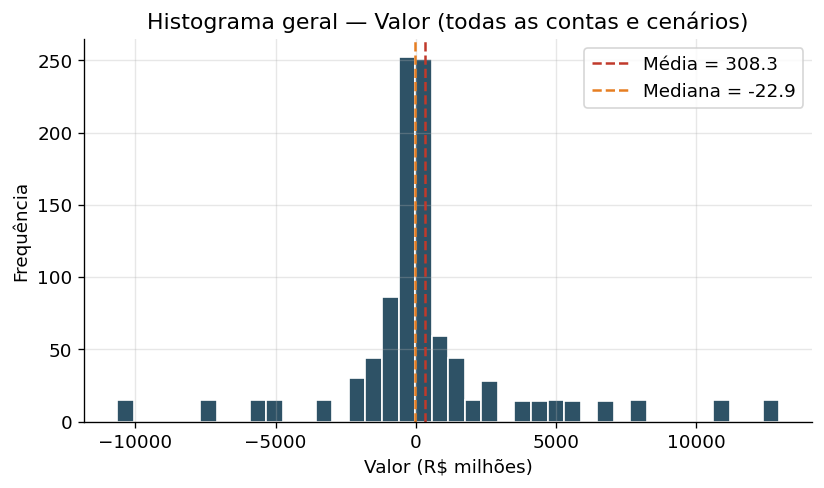

In [ ]:
fig, ax = plt.subplots(figsize=(7,4.2))
ax.hist(df['valor_mi'], bins=40, color='#2E5266', edgecolor='white')
ax.axvline(df['valor_mi'].mean(), color='#C0392B', linestyle='--', lw=1.5,
           label=f"Média = {df['valor_mi'].mean():.1f}")
ax.axvline(df['valor_mi'].median(), color='#E67E22', linestyle='--', lw=1.5,
           label=f"Mediana = {df['valor_mi'].median():.1f}")
ax.set_xlabel('Valor (R$ milhões)'); ax.set_ylabel('Frequência')
ax.set_title('Histograma geral — Valor (todas as contas e cenários)')
ax.legend()
plt.tight_layout(); plt.show()

### 7.2 Histogramas por demonstrativo

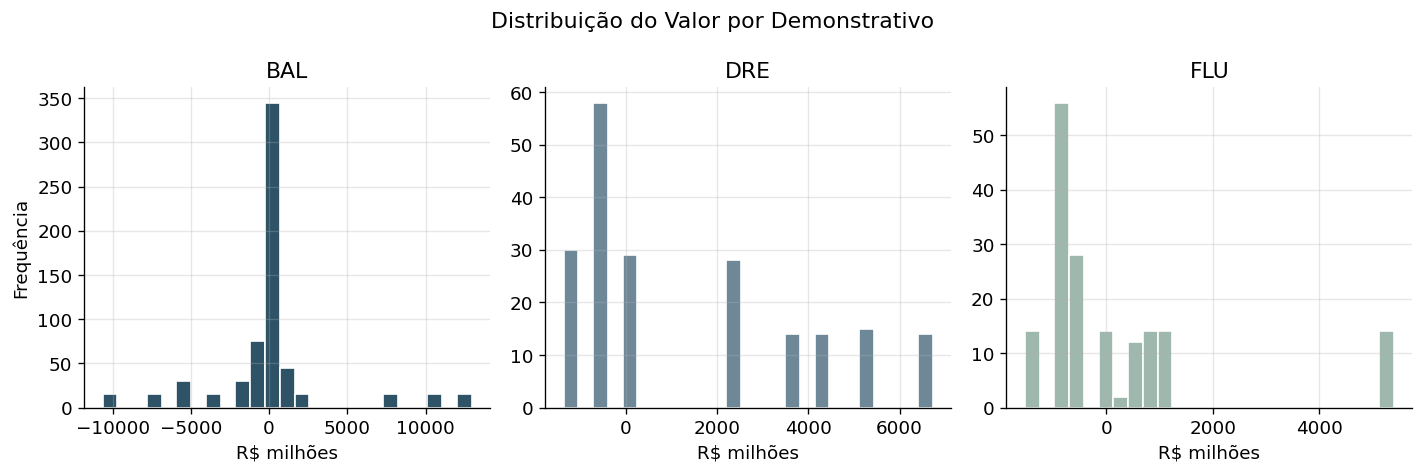

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, dem in zip(axes, ['BAL','DRE','FLU']):
    d = df[df['demonstrativo']==dem]['valor_mi']
    ax.hist(d, bins=25, color=COLORS[dem], edgecolor='white')
    ax.set_title(dem); ax.set_xlabel('R$ milhões')
axes[0].set_ylabel('Frequência')
fig.suptitle('Distribuição do Valor por Demonstrativo')
plt.tight_layout(); plt.show()

### 7.3 Boxplot geral

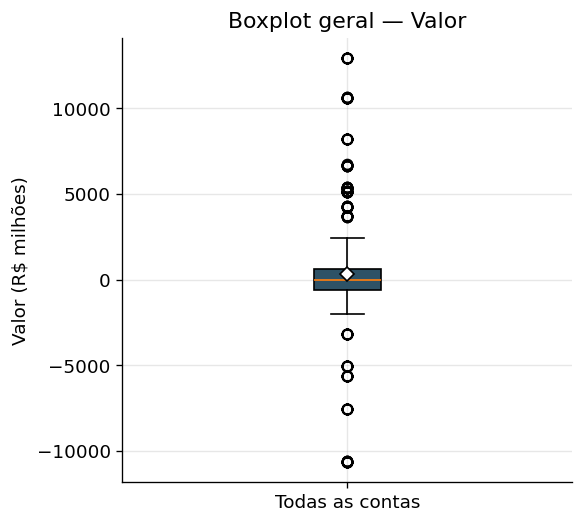

In [ ]:
fig, ax = plt.subplots(figsize=(5,4.5))
bp = ax.boxplot(df['valor_mi'], patch_artist=True, showmeans=True, tick_labels=['Todas as contas'],
                meanprops={'marker':'D','markerfacecolor':'white','markeredgecolor':'black'})
bp['boxes'][0].set_facecolor('#2E5266')
ax.set_ylabel('Valor (R$ milhões)'); ax.set_title('Boxplot geral — Valor')
plt.tight_layout(); plt.show()

### 7.4 Boxplot por demonstrativo

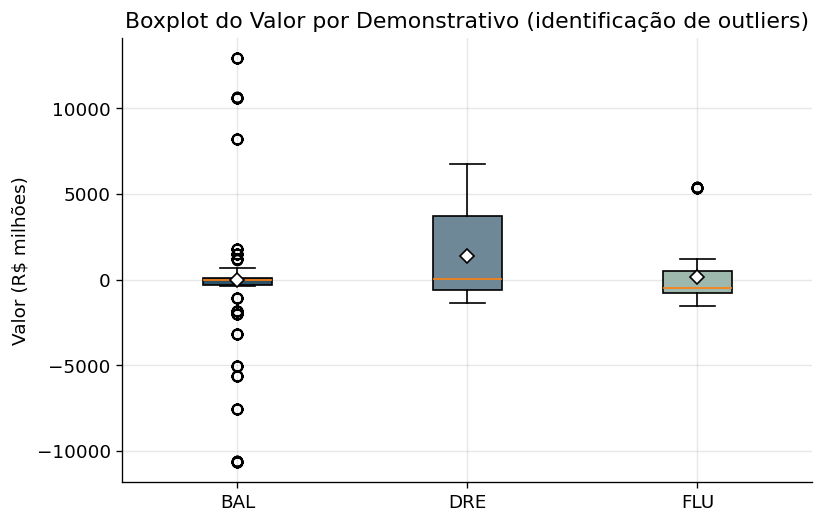

In [ ]:
fig, ax = plt.subplots(figsize=(7,4.5))
data = [df[df['demonstrativo']==d]['valor_mi'] for d in ['BAL','DRE','FLU']]
bp = ax.boxplot(data, tick_labels=['BAL','DRE','FLU'], patch_artist=True, showmeans=True,
                meanprops={'marker':'D','markerfacecolor':'white','markeredgecolor':'black'})
for patch, dem in zip(bp['boxes'], ['BAL','DRE','FLU']):
    patch.set_facecolor(COLORS[dem])
ax.set_ylabel('Valor (R$ milhões)')
ax.set_title('Boxplot do Valor por Demonstrativo (identificação de outliers)')
plt.tight_layout(); plt.show()

### 7.5 Boxplot das contas com maior variância entre cenários

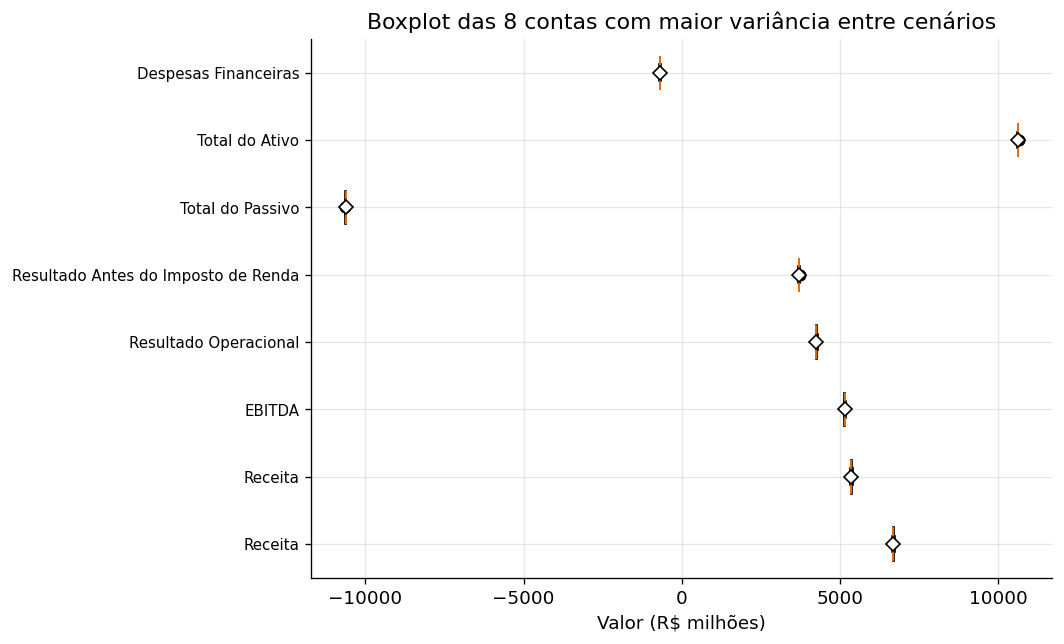

In [ ]:
top_contas = var_por_conta.head(8).index.tolist()
data = [df[df['conta_normalizada']==c]['valor_mi'] for c in top_contas]
labels = [c.split(' - ',1)[1] for c in top_contas]

fig, ax = plt.subplots(figsize=(9,5.5))
bp = ax.boxplot(data, patch_artist=True, showmeans=True, vert=False,
                meanprops={'marker':'D','markerfacecolor':'white','markeredgecolor':'black'})
for patch, c in zip(bp['boxes'], top_contas):
    dem = c.split(' - ')[0].strip()
    patch.set_facecolor(COLORS.get(dem, '#888'))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Valor (R$ milhões)')
ax.set_title('Boxplot das 8 contas com maior variância entre cenários')
plt.tight_layout(); plt.show()